# Prior Sensitivity Analysis on Province Model

In [1]:
from pathlib import Path
import os, stat
from tqdm import tqdm

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel

/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project_root = Path('..').resolve()
stan_path = project_root / 'stan' / 'logistic_province_prior_sensitivity.stan'
out_root = Path.cwd() / 'stan_output' / 'sensitivity_province'
out_root.mkdir(parents=True, exist_ok=True)

def compile_model(stan_path):
    print('Compiling', stan_path.name)
    mdl = CmdStanModel(stan_file=str(stan_path))
    mode = os.stat(mdl.exe_file).st_mode
    os.chmod(mdl.exe_file, mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)
    return mdl

In [3]:
df = pd.read_csv('../data/fire_db.csv')
df_proc = df.dropna(subset=['any_evacuation', 'log_fire_size_ha', 'fn_indicator', 'province']).copy()
prov_cat = pd.Categorical(df_proc['province'])
df_proc['prov_idx'] = prov_cat.codes + 1

base_data = {
    'N': len(df_proc),
    'P': len(prov_cat.categories),
    'province': df_proc['prov_idx'].astype(int).tolist(),
    'y': df_proc['any_evacuation'].astype(int).tolist(),
    'log_fire_size': df_proc['log_fire_size_ha'].astype(float).tolist(),
    'fn_indicator': df_proc['fn_indicator'].astype(int).tolist(),
}

print(f'N = {base_data["N"]}, P = {base_data["P"]}')

N = 15203, P = 12


In [4]:
baseline_priors = {
    'sigma_alpha': 2.0,
    'sigma_prov': 1.0,
    'sigma_beta_log_fire_size': 1.0,
    'sigma_beta_fn': 1.0,
}

print('Baseline priors:')
for k, v in baseline_priors.items():
    print(f'  {k}: {v}')

Baseline priors:
  sigma_alpha: 2.0
  sigma_prov: 1.0
  sigma_beta_log_fire_size: 1.0
  sigma_beta_fn: 1.0


In [5]:
mdl_sens = compile_model(stan_path)

Compiling logistic_province_prior_sensitivity.stan


## Half All

In [6]:
half_all_priors = {k: v * 0.5 for k, v in baseline_priors.items()}

data_half_all = dict(base_data)
for k, v in half_all_priors.items():
    data_half_all[k] = v

print('Half all prior configuration:')
for k, v in half_all_priors.items():
    print(f'  {k}: {v}')

Half all prior configuration:
  sigma_alpha: 1.0
  sigma_prov: 0.5
  sigma_beta_log_fire_size: 0.5
  sigma_beta_fn: 0.5


In [7]:
run_dir_half = out_root / 'half_all'
run_dir_half.mkdir(parents=True, exist_ok=True)
idata_path_half = run_dir_half / 'idata.nc'

if idata_path_half.exists():
    print('Loading cached idata for half_all')
    idata_half = az.from_netcdf(str(idata_path_half))
else:
    print('Sampling half_all...')
    fit_half = mdl_sens.sample(
        data=data_half_all,
        chains=4,
        parallel_chains=min(4, os.cpu_count() or 1),
        iter_warmup=500,
        iter_sampling=1000,
        seed=20260419,
        adapt_delta=0.95,
        show_console=False,
        output_dir=str(run_dir_half),
        save_warmup=False,
    )
    idata_half = az.from_cmdstanpy(
        posterior=fit_half,
        log_likelihood='log_lik',
    )
    idata_half.to_netcdf(str(idata_path_half))
    print('Saved idata to', idata_path_half)

Sampling half_all...


23:16:48 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]





chain 1:   7%|▋         | 100/1500 [00:11<02:39,  8.80it/s, (Warmup)]


chain 1:  13%|█▎        | 200/1500 [00:19<02:06, 10.27it/s, (Warmup)]


chain 1:  20%|██        | 300/1500 [00:25<01:32, 12.91it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [00:29<01:11, 15.39it/s, (Warmup)]

chain 1:  33%|███▎      | 500/1500 [00:34<00:59, 16.92it/s, (Sampling)]




chain 1:  40%|████      | 600/1500 [00:41<00:57, 15.77it/s, (Sampling)]




chain 1:  53%|█████▎    | 800/1500 [00:55<00:46, 15.21it/s, (Sampling)]




chain 1:  60%|██████    | 900/1500 [01:02<00:39, 15.18it/s, (Sampling)]



chain 1:  67%|██████▋   | 1000/1500 [01:10<00:35, 14.24it/s, (Sampling)]


chain 1:  73%|███████▎  | 1100/1500 [01:16<00:27, 14.46it/s, (Sampling)]


chain 1:  80%|████████  | 1200/1500 [01:22<00:19, 15.14it/s, (Sampling)]


chain 1:  87%|████████▋ | 1300/1500 [01:28<00:12, 15.74it/s, (Sam


23:18:28 - cmdstanpy - INFO - CmdStan done processing.



Saved idata to /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/notebooks/stan_output/sensitivity_province/half_all/idata.nc


In [8]:
loo_half = az.loo(idata_half, pointwise=True)
print(loo_half)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2023.38    66.18
p_loo        9.21        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [9]:
summ_half = az.summary(idata_half, var_names=['alpha', 'beta_log_fire_size', 'beta_fn'])
summ_half

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-3.81,0.176,-4.1,-3.5,701,1099,1.00,0.0067,0.0048
beta_log_fire_size,0.473,0.041,0.41,0.54,3390,2993,1.00,0.00071,0.00051
beta_fn,1.086,0.204,0.76,1.4,3841,2811,1.00,0.0033,0.0023


## Baseline

In [10]:
data_baseline = dict(base_data)
for k, v in baseline_priors.items():
    data_baseline[k] = v

print('Baseline prior configuration:')
for k, v in baseline_priors.items():
    print(f'  {k}: {v}')

Baseline prior configuration:
  sigma_alpha: 2.0
  sigma_prov: 1.0
  sigma_beta_log_fire_size: 1.0
  sigma_beta_fn: 1.0


In [11]:
run_dir_base = out_root / 'baseline'
run_dir_base.mkdir(parents=True, exist_ok=True)
idata_path_base = run_dir_base / 'idata.nc'

if idata_path_base.exists():
    print('Loading cached idata for baseline')
    idata_baseline = az.from_netcdf(str(idata_path_base))
else:
    print('Sampling baseline...')
    fit_baseline = mdl_sens.sample(
        data=data_baseline,
        chains=4,
        parallel_chains=min(4, os.cpu_count() or 1),
        iter_warmup=500,
        iter_sampling=1000,
        seed=20260419,
        adapt_delta=0.95,
        show_console=False,
        output_dir=str(run_dir_base),
        save_warmup=False,
    )
    idata_baseline = az.from_cmdstanpy(
        posterior=fit_baseline,
        log_likelihood='log_lik',
    )
    idata_baseline.to_netcdf(str(idata_path_base))
    print('Saved idata to', idata_path_base)

Sampling baseline...


23:19:13 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]



chain 1:   0%|          | 1/1500 [00:00<03:07,  8.01it/s, (Warmup)]


chain 1:   7%|▋         | 100/1500 [00:34<07:58,  2.93it/s, (Warmup)]




chain 1:  13%|█▎        | 200/1500 [00:58<06:10,  3.51it/s, (Warmup)]


chain 1:  20%|██        | 300/1500 [01:11<04:16,  4.68it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [01:24<03:17,  5.58it/s, (Warmup)]







chain 1:  33%|███▎      | 500/1500 [01:36<02:37,  6.33it/s, (Sampling)]


chain 1:  40%|████      | 600/1500 [01:46<02:06,  7.14it/s, (Sampling)]


chain 1:  47%|████▋     | 700/1500 [01:55<01:38,  8.16it/s, (Sampling)]


chain 1:  53%|█████▎    | 800/1500 [02:04<01:18,  8.93it/s, (Sampling)]


chain 1:  60%|██████    | 900/1500 [02:12<01:02,  9.61it/s, (Sampling)]


chain 1:  67%|██████▋   | 1000/1500 [02:21<00:48, 10.27it/s, (Sampling)]


chain 1:  73%|███████▎  | 1100/1500 [02:30<00:37, 10.54it/s, (Sampling)]


23:22:27 - cmdstanpy - INFO - CmdStan done processing.



Saved idata to /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/notebooks/stan_output/sensitivity_province/baseline/idata.nc


In [12]:
loo_baseline = az.loo(idata_baseline, pointwise=True)
print(loo_baseline)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2019.05    66.51
p_loo       10.65        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [13]:
summ_baseline = az.summary(idata_baseline, var_names=['alpha', 'beta_log_fire_size', 'beta_fn'])
summ_baseline

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-4.06,0.31,-4.6,-3.5,647,806,1.00,0.012,0.0087
beta_log_fire_size,0.486,0.0404,0.42,0.55,4504,3000,1.00,0.0006,0.00042
beta_fn,1.213,0.205,0.88,1.5,4408,2823,1.00,0.0031,0.0023


## Configuration 3: Double All

In [14]:
double_all_priors = {k: v * 2.0 for k, v in baseline_priors.items()}

data_double_all = dict(base_data)
for k, v in double_all_priors.items():
    data_double_all[k] = v

print('Double all prior configuration:')
for k, v in double_all_priors.items():
    print(f'  {k}: {v}')

Double all prior configuration:
  sigma_alpha: 4.0
  sigma_prov: 2.0
  sigma_beta_log_fire_size: 2.0
  sigma_beta_fn: 2.0


In [15]:
run_dir_double = out_root / 'double_all'
run_dir_double.mkdir(parents=True, exist_ok=True)
idata_path_double = run_dir_double / 'idata.nc'

if idata_path_double.exists():
    print('Loading cached idata for double_all')
    idata_double = az.from_netcdf(str(idata_path_double))
else:
    print('Sampling double_all...')
    fit_double = mdl_sens.sample(
        data=data_double_all,
        chains=4,
        parallel_chains=min(4, os.cpu_count() or 1),
        iter_warmup=500,
        iter_sampling=1000,
        seed=20260419,
        adapt_delta=0.95,
        show_console=False,
        output_dir=str(run_dir_double),
        save_warmup=False,
    )
    idata_double = az.from_cmdstanpy(
        posterior=fit_double,
        log_likelihood='log_lik',
    )
    idata_double.to_netcdf(str(idata_path_double))
    print('Saved idata to', idata_path_double)

Sampling double_all...


23:23:04 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]



chain 1:   7%|▋         | 100/1500 [00:23<05:33,  4.20it/s, (Warmup)]

chain 1:  13%|█▎        | 200/1500 [00:42<04:26,  4.88it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [01:09<02:57,  6.20it/s, (Warmup)]


chain 1:  33%|███▎      | 501/1500 [01:30<02:57,  5.63it/s, (Sampling)]




chain 1:  40%|████      | 600/1500 [01:46<02:33,  5.85it/s, (Sampling)]





chain 1:  53%|█████▎    | 800/1500 [02:18<01:55,  6.06it/s, (Sampling)]


chain 1:  60%|██████    | 900/1500 [02:33<01:35,  6.29it/s, (Sampling)]

chain 1:  73%|███████▎  | 1100/1500 [03:00<00:58,  6.82it/s, (Sampling)]


chain 1:  87%|████████▋ | 1300/1500 [03:29<00:29,  6.84it/s, (Sampling)]

chain 1:  93%|█████████▎| 1400/1500 [03:43<00:14,  7.00it/s, (Sampling)]


chain 1: 100%|██████████| 1500/1500 [03:57<00:00,  7.00it/s, (Sampling)]













chain 2: 100%|██████████| 1500/1500 [05:07<00:00,  4.87it


23:28:12 - cmdstanpy - INFO - CmdStan done processing.



Saved idata to /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/notebooks/stan_output/sensitivity_province/double_all/idata.nc


In [16]:
loo_double = az.loo(idata_double, pointwise=True)
print(loo_double)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2018.05    66.69
p_loo       11.13        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [17]:
summ_double = az.summary(idata_double, var_names=['alpha', 'beta_log_fire_size', 'beta_fn'])
summ_double

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-4.35,0.59,-5.3,-3.4,619,989,1.00,0.024,0.016
beta_log_fire_size,0.49,0.042,0.42,0.56,3038,2579,1.00,0.00077,0.00053
beta_fn,1.258,0.209,0.92,1.6,3069,2677,1.00,0.0038,0.0026


## Comparison

In [18]:
model_idata = {
    'half_all': idata_half,
    'baseline': idata_baseline,
    'double_all': idata_double,
}
print('Loaded sensitivity configurations:', list(model_idata.keys()))

Loaded sensitivity configurations: ['half_all', 'baseline', 'double_all']


In [19]:
loo_dict = {
    'half_all': loo_half,
    'baseline': loo_baseline,
    'double_all': loo_double,
}

comp_sensitivity = az.compare(loo_dict, round_to='none')
comp_sensitivity

,rank,elpd,p,elpd_diff,weight,se,dse,warning
double_all,0,-2018.052750,11.126053,0.000000,1.000000e+00,66.686373,0.000000,False
baseline,1,-2019.054926,10.650220,1.002176,3.497203e-15,66.511112,0.773709,False
half_all,2,-2023.378318,9.213468,5.325568,0.000000e+00,66.182513,2.777254,False


In [20]:
def _as_float_or_nan(x):
    try:
        return float(x)
    except Exception:
        return float('nan')

def _extract_elpd_and_se(loo_obj):
    elpd = None
    for attr in ['elpd_loo', 'elpd', 'loo', 'estimate']:
        if hasattr(loo_obj, attr):
            elpd = getattr(loo_obj, attr)
            break
    if elpd is None and hasattr(loo_obj, 'to_dict'):
        d = loo_obj.to_dict()
        for key in ['elpd_loo', 'elpd', 'loo', 'estimate']:
            if key in d:
                elpd = d[key]
                break

    se = None
    for attr in ['se', 'elpd_se', 'standard_error']:
        if hasattr(loo_obj, attr):
            se = getattr(loo_obj, attr)
            break
    if se is None and hasattr(loo_obj, 'to_dict'):
        d = loo_obj.to_dict()
        for key in ['se', 'elpd_se', 'standard_error']:
            if key in d:
                se = d[key]
                break

    return _as_float_or_nan(elpd), _as_float_or_nan(se)

rows = []
for name, (priors, idata, loo) in [
    ('half_all', (half_all_priors, idata_half, loo_half)),
    ('baseline', (baseline_priors, idata_baseline, loo_baseline)),
    ('double_all', (double_all_priors, idata_double, loo_double)),
]:
    elpd_val, se_val = _extract_elpd_and_se(loo)
    rows.append({
        'name': name,
        'sigma_alpha': priors['sigma_alpha'],
        'sigma_prov': priors['sigma_prov'],
        'sigma_beta_log_fire_size': priors['sigma_beta_log_fire_size'],
        'sigma_beta_fn': priors['sigma_beta_fn'],
        'elpd': elpd_val,
        'elpd_se': se_val,
        'alpha_mean': float(idata.posterior['alpha'].values.mean()),
        'beta_log_fire_size_mean': float(idata.posterior['beta_log_fire_size'].values.mean()),
        'beta_fn_mean': float(idata.posterior['beta_fn'].values.mean()),
    })

results_df = pd.DataFrame(rows).sort_values('name').reset_index(drop=True)
results_df.to_csv(out_root / 'results_summary.csv', index=False)
results_df

,name,sigma_alpha,sigma_prov,sigma_beta_log_fire_size,sigma_beta_fn,elpd,elpd_se,alpha_mean,beta_log_fire_size_mean,beta_fn_mean
0,baseline,2.0,1.0,1.0,1.0,-2019.054926,66.511112,-4.058001,0.485617,1.213046
1,double_all,4.0,2.0,2.0,2.0,-2018.052750,66.686373,-4.347124,0.489837,1.257773
2,half_all,1.0,0.5,0.5,0.5,-2023.378318,66.182513,-3.805307,0.473014,1.086243


In [21]:
baseline_row = results_df[results_df['name'] == 'baseline'].iloc[0]

stability = results_df.copy()
stability['delta_elpd'] = stability['elpd'] - baseline_row['elpd']
stability['delta_alpha'] = stability['alpha_mean'] - baseline_row['alpha_mean']
stability['delta_beta_log_fire_size'] = stability['beta_log_fire_size_mean'] - baseline_row['beta_log_fire_size_mean']
stability['delta_beta_fn'] = stability['beta_fn_mean'] - baseline_row['beta_fn_mean']

stability = stability[[
    'name',
    'sigma_alpha', 'sigma_prov', 'sigma_beta_log_fire_size', 'sigma_beta_fn',
    'elpd', 'delta_elpd',
    'alpha_mean', 'delta_alpha',
    'beta_log_fire_size_mean', 'delta_beta_log_fire_size',
    'beta_fn_mean', 'delta_beta_fn',
]]
stability.sort_values('delta_elpd', ascending=False)

,name,sigma_alpha,sigma_prov,sigma_beta_log_fire_size,sigma_beta_fn,elpd,delta_elpd,alpha_mean,delta_alpha,beta_log_fire_size_mean,delta_beta_log_fire_size,beta_fn_mean,delta_beta_fn
1,double_all,4.0,2.0,2.0,2.0,-2018.052750,1.002176,-4.347124,-0.289122,0.489837,0.004220,1.257773,0.044727
0,baseline,2.0,1.0,1.0,1.0,-2019.054926,0.000000,-4.058001,0.000000,0.485617,0.000000,1.213046,0.000000
2,half_all,1.0,0.5,0.5,0.5,-2023.378318,-4.323392,-3.805307,0.252694,0.473014,-0.012603,1.086243,-0.126804


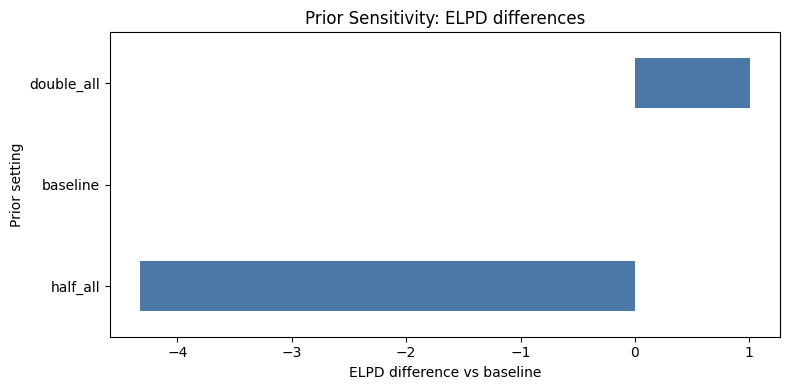

In [22]:
ax = stability.set_index('name')['delta_elpd'].sort_values().plot(kind='barh', figsize=(8, 4), color='#4c78a8')
ax.set_xlabel('ELPD difference vs baseline')
ax.set_ylabel('Prior setting')
ax.set_title('Prior Sensitivity: ELPD differences')
plt.tight_layout()
plt.show()

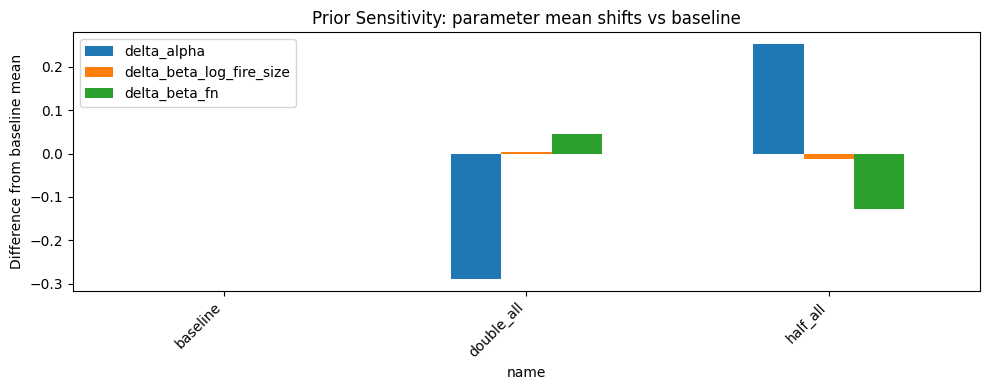

In [23]:
param_deltas = stability.set_index('name')[['delta_alpha', 'delta_beta_log_fire_size', 'delta_beta_fn']]
ax = param_deltas.plot(kind='bar', figsize=(10, 4))
ax.set_title('Prior Sensitivity: parameter mean shifts vs baseline')
ax.set_ylabel('Difference from baseline mean')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
comp_sensitivity = (
    results_df[['name', 'elpd', 'elpd_se']]
    .assign(delta_vs_best=lambda d: d['elpd'] - d['elpd'].max())
    .sort_values('elpd', ascending=False)
    .reset_index(drop=True)
)
comp_sensitivity

,name,elpd,elpd_se,delta_vs_best
0,double_all,-2018.052750,66.686373,0.000000
1,baseline,-2019.054926,66.511112,-1.002176
2,half_all,-2023.378318,66.182513,-5.325568


In [25]:
baseline_row = results_df[results_df['name'] == 'baseline'].iloc[0]

stability = results_df.copy()
stability['delta_elpd'] = stability['elpd'] - baseline_row['elpd']
stability['delta_alpha'] = stability['alpha_mean'] - baseline_row['alpha_mean']
stability['delta_beta_log_fire_size'] = stability['beta_log_fire_size_mean'] - baseline_row['beta_log_fire_size_mean']
stability['delta_beta_fn'] = stability['beta_fn_mean'] - baseline_row['beta_fn_mean']

stability = stability[[
    'name',
    'sigma_alpha', 'sigma_prov', 'sigma_beta_log_fire_size', 'sigma_beta_fn',
    'elpd', 'delta_elpd',
    'alpha_mean', 'delta_alpha',
    'beta_log_fire_size_mean', 'delta_beta_log_fire_size',
    'beta_fn_mean', 'delta_beta_fn',
]]
stability.sort_values('delta_elpd', ascending=False)

,name,sigma_alpha,sigma_prov,sigma_beta_log_fire_size,sigma_beta_fn,elpd,delta_elpd,alpha_mean,delta_alpha,beta_log_fire_size_mean,delta_beta_log_fire_size,beta_fn_mean,delta_beta_fn
1,double_all,4.0,2.0,2.0,2.0,-2018.052750,1.002176,-4.347124,-0.289122,0.489837,0.004220,1.257773,0.044727
0,baseline,2.0,1.0,1.0,1.0,-2019.054926,0.000000,-4.058001,0.000000,0.485617,0.000000,1.213046,0.000000
2,half_all,1.0,0.5,0.5,0.5,-2023.378318,-4.323392,-3.805307,0.252694,0.473014,-0.012603,1.086243,-0.126804


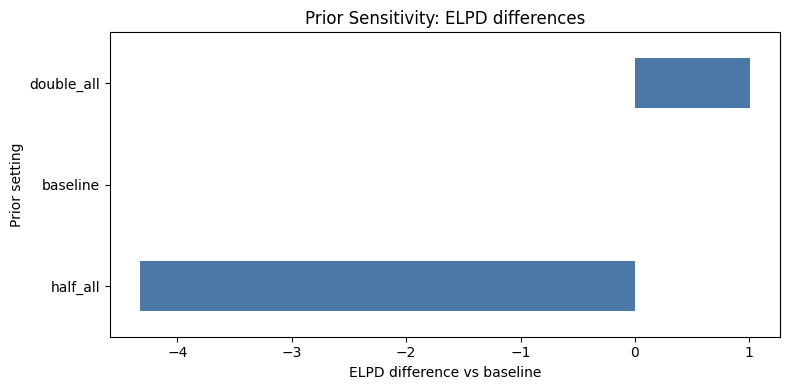

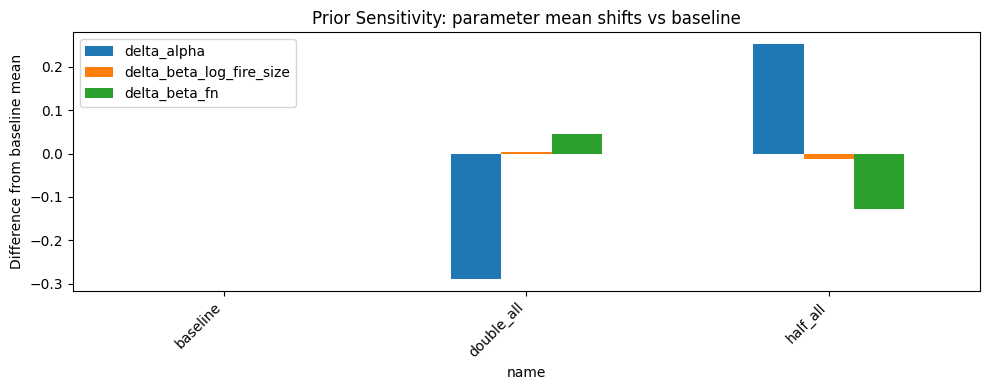

In [26]:
ax = stability.set_index('name')['delta_elpd'].sort_values().plot(kind='barh', figsize=(8, 4), color='#4c78a8')
ax.set_xlabel('ELPD difference vs baseline')
ax.set_ylabel('Prior setting')
ax.set_title('Prior Sensitivity: ELPD differences')
plt.tight_layout()
plt.show()

param_deltas = stability.set_index('name')[['delta_alpha', 'delta_beta_log_fire_size', 'delta_beta_fn']]
ax = param_deltas.plot(kind='bar', figsize=(10, 4))
ax.set_title('Prior Sensitivity: parameter mean shifts vs baseline')
ax.set_ylabel('Difference from baseline mean')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()